# Let's do some Ragging(Retrieval Augmented Generation )


## Problem to be solved
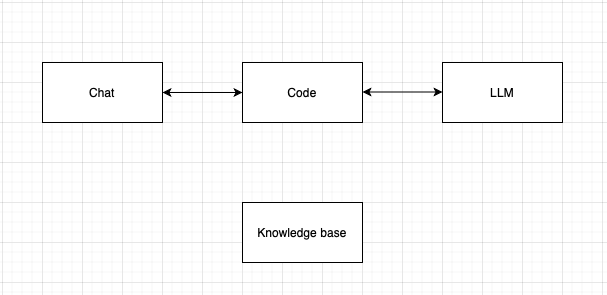


- LLMs can only answer based on trained data like:
    - Knowledge learned during training
    - Licensed data
    - Publicly available data
- How can we feed the Knowledge which we have in our internal system?
    - Tools
    - RAG


### Difference between Tools and RAG
    - Tools
        - User asks question
        - LLM decides it needs tools
        - LLM calls the tool
        - Tools return structured result
        - LLM uses results to answer
    - RAG
        - User asks question
        - System searches knowledge source
        - Retrieved content is added to prompt
        - LLM generates answer

## Tools
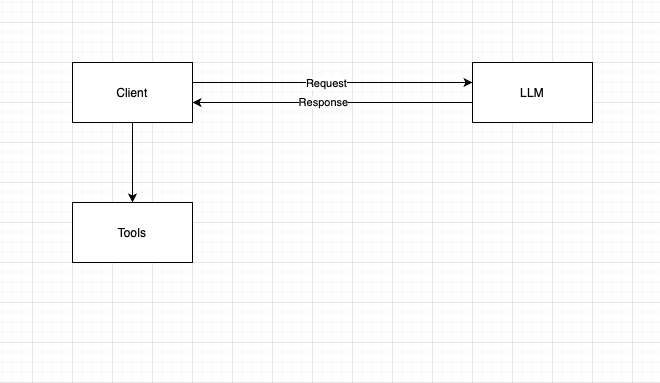



In [233]:
# import required library
import os
from dotenv import load_dotenv
from openai import OpenAI
import sqlite3
import random
from datetime import datetime, timedelta
import json
import gradio as gr
import fitz
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_community.embeddings import OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import SystemMessage, HumanMessage
import glob

In [234]:
## Create a SQL Lite data base

DB = "maintenance.db"

## Create equipment and maintenance plan tables
# Connect database
conn = sqlite3.connect("maintenance.db")
cursor = conn.cursor()

# Enable foreign keys
cursor.execute("PRAGMA foreign_keys = ON")

# -------------------------
# Create Equipment Table
# -------------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS equipment (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    serial_number TEXT UNIQUE,
    location TEXT,
    purchase_date TEXT,
    status TEXT
)
""")

# -------------------------
# Create Maintenance Plan Table
# -------------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS maintenance_plan (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    equipment_id INTEGER,
    maintenance_type TEXT,
    frequency_days INTEGER,
    last_maintenance TEXT,
    next_due TEXT,
    FOREIGN KEY (equipment_id)
        REFERENCES equipment(id)
        ON DELETE CASCADE
)
""")

# -------------------------
# Sample Data Pools
# -------------------------
equipment_types = [
    "Pump", "Compressor", "Generator", "Motor",
    "Conveyor", "Boiler", "Fan", "Chiller"
]

locations = ["Plant A", "Plant B", "Warehouse", "Unit 1", "Unit 2"]
statuses = ["Active", "Inactive"]
maintenance_types = ["Preventive", "Inspection", "Calibration"]

# -------------------------
# Helper Function
# -------------------------
def random_date(start_year=2020, end_year=2024):
    start = datetime(start_year, 1, 1)
    end = datetime(end_year, 12, 31)
    delta = end - start
    random_days = random.randint(0, delta.days)
    return start + timedelta(days=random_days)

# -------------------------
# Insert 100 Equipments
# -------------------------
equipment_ids = []

for i in range(1, 101):
    name = f"{random.choice(equipment_types)}-{i}"
    serial = f"SN-{1000+i}"
    location = random.choice(locations)
    purchase_date = random_date().strftime("%Y-%m-%d")
    status = random.choice(statuses)

    cursor.execute("""
        INSERT INTO equipment
        (name, serial_number, location, purchase_date, status)
        VALUES (?, ?, ?, ?, ?)
    """, (name, serial, location, purchase_date, status))

    equipment_ids.append(cursor.lastrowid)

# -------------------------
# Insert Maintenance Plans
# -------------------------
for eq_id in equipment_ids:
    frequency = random.choice([7, 15, 30, 60, 90])

    last_maintenance = datetime.now() - timedelta(days=random.randint(1, 60))
    next_due = last_maintenance + timedelta(days=frequency)

    cursor.execute("""
        INSERT INTO maintenance_plan
        (equipment_id, maintenance_type, frequency_days,
         last_maintenance, next_due)
        VALUES (?, ?, ?, ?, ?)
    """, (
        eq_id,
        random.choice(maintenance_types),
        frequency,
        last_maintenance.strftime("%Y-%m-%d"),
        next_due.strftime("%Y-%m-%d")
    ))

# -------------------------
# Commit & Verify
# -------------------------
# Save changes
conn.commit()

conn.close()

In [235]:
# Connect database
conn = sqlite3.connect("maintenance.db")
cursor = conn.cursor()

cursor.execute("""
SELECT e.id,e.name, e.location, m.maintenance_type, m.next_due
FROM equipment e
JOIN maintenance_plan m
ON e.id = m.equipment_id
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(1, 'Chiller-1', 'Unit 1', 'Calibration', '2026-05-29')
(2, 'Pump-2', 'Warehouse', 'Preventive', '2026-06-14')
(3, 'Motor-3', 'Warehouse', 'Preventive', '2026-02-03')
(4, 'Conveyor-4', 'Warehouse', 'Preventive', '2026-01-29')
(5, 'Fan-5', 'Plant A', 'Preventive', '2026-04-01')
(6, 'Chiller-6', 'Unit 1', 'Inspection', '2026-03-20')
(7, 'Motor-7', 'Plant A', 'Calibration', '2026-02-25')
(8, 'Chiller-8', 'Plant B', 'Inspection', '2026-04-12')
(9, 'Fan-9', 'Warehouse', 'Preventive', '2026-03-18')
(10, 'Conveyor-10', 'Warehouse', 'Preventive', '2026-03-17')
(11, 'Motor-11', 'Unit 2', 'Calibration', '2026-04-21')
(12, 'Generator-12', 'Plant A', 'Calibration', '2026-02-19')
(13, 'Fan-13', 'Plant A', 'Calibration', '2026-04-23')
(14, 'Generator-14', 'Plant B', 'Inspection', '2026-02-02')
(15, 'Fan-15', 'Unit 1', 'Inspection', '2026-03-30')
(16, 'Boiler-16', 'Plant A', 'Preventive', '2026-04-08')
(17, 'Compressor-17', 'Unit 1', 'Calibration', '2026-02-25')
(18, 'Pump-18', 'Unit 2', 'Preventive'

In [236]:
# Creating tools method
def get_maintenance_type(equipment):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
    cursor.execute(' SELECT m.maintenance_type FROM equipment e JOIN maintenance_plan m ON e.id = m.equipment_id where e.name = ? ', (equipment,))
    result = cursor.fetchone()
    return f"Maintenance type for {equipment} is ${result[0]}" if result else "No Maintenance type available for this equipment"

In [ ]:
# Creating tools function
maintenance_function = {
    "name": "get_maintenance_type",
    "description": "Get the maintenance type for given equipment.",
    "parameters": {
        "type": "object",
        "properties": {
            "equipment": {
                "type": "string",
                "description": "This is the equipment for which he need to find maintenance type",
            },
        },
        "required": ["equipment"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": maintenance_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_maintenance_type',
   'description': 'Get the maintenance type for given equipment.',
   'parameters': {'type': 'object',
    'properties': {'equipment': {'type': 'string',
      'description': 'This is the equipment for which he need to find maintenance type'}},
    'required': ['equipment'],
    'additionalProperties': False}}}]

In [238]:

def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_maintenance_type":
            arguments = json.loads(tool_call.function.arguments)
            print(arguments)
            equipment = arguments.get('equipment')
            maintenance_type = get_maintenance_type(equipment)
            responses.append({
                "role": "tool",
                "content": maintenance_type,
                "tool_call_id": tool_call.id
            })
    return responses

In [239]:

load_dotenv(override=True)
api_key = os.getenv('OPENAI_API_KEY')

# Check the key

if not api_key:
    print("No API key was found - please head over to the troubleshooting notebook in this folder to identify & fix!")
elif not api_key.startswith("sk-proj-"):
    print("An API key was found, but it doesn't start sk-proj-; please check you're using the right key - see troubleshooting notebook")
elif api_key.strip() != api_key:
    print("An API key was found, but it looks like it might have space or tab characters at the start or end - please remove them - see troubleshooting notebook")
else:
    print("API key found and looks good so far!")

openai = OpenAI()

API key found and looks good so far!


In [ ]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages, tools=tools)
    
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7886
* To create a public link, set `share=True` in `launch()`.


{'equipment': 'pump-19'}
{'equipment': 'Pump-19'}


In [241]:
OLLAMA_BASE_URL = "http://localhost:11434/v1"

ollama = OpenAI(base_url=OLLAMA_BASE_URL, api_key='fhsdjkfhsdj')

In [242]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = ollama.chat.completions.create(model="gemma3:4b", messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = ollama.chat.completions.create(model="gemma3:4b", messages=messages, tools=tools)
    
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7887
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/Users/I072374/Sharath/Projects/AILearning/AILearning/LLM/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/I072374/Sharath/Projects/AILearning/AILearning/LLM/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/I072374/Sharath/Projects/AILearning/AILearning/LLM/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/I072374/Sharath/Projects/AILearning/AILearning/LLM/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^


In [243]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = ollama.chat.completions.create(model="llama3.1", messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = ollama.chat.completions.create(model="llama3.1", messages=messages, tools=tools)
    
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7888
* To create a public link, set `share=True` in `launch()`.


## RAG

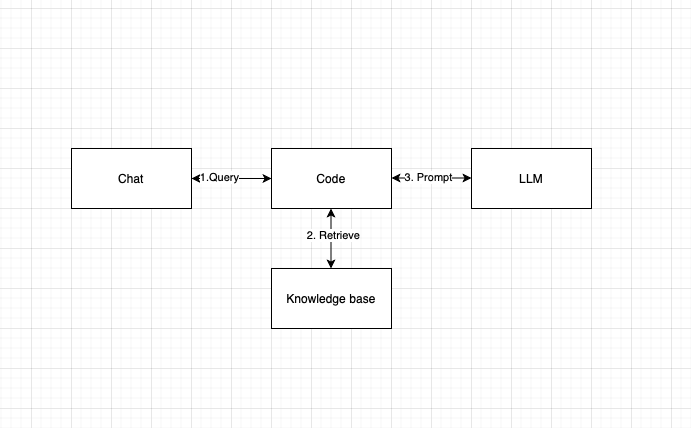

- User asks a question
- We will Retrieve the related information from Knowledge base
    - Database
    - Documents
    - APIs
- We will then ask Prompt to LLM.
- Two steps for RAG
    - Creation of Knowledge base
    - Consume the data from knowledge base

### Preparation of data

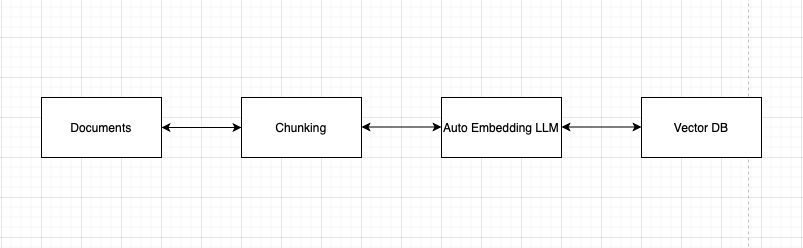

### Terminologies
- Auto Regressive LLM
    - An auto-regressive LLM generates text one token at a time, where each new token depends on all previously generated tokens.
    - Examples:
        - GPT
        - Claude
        - Gemini
        - Gemma
- Auto Embedding LLM
    - An auto-encoding model learns to understand text by encoding the entire input at once, usually to extract meaning, not to generate text step-by-step.
        - Example:
            - EmbeddingGemma
            - BERT
- Vector DB
    - A vector database (vector DB) is a database designed to store and search vectors (embeddings) instead of normal text or numbers.
        - Example:
            - Chroma
            - S/4HANA Vector storage

In [245]:

# Initialize embedding model via Ollama
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Input text
text = "H"

# Create embedding
vector = embeddings.embed_query(text)

# Display results
print("Text:", text)
print("\nEmbedding vector (first 10 values):")
print(vector[:10])

print("\nVector length:", len(vector))

Text: H

Embedding vector (first 10 values):
[-0.01738010346889496, -0.07771209627389908, -3.7048611640930176, -0.13193796575069427, 1.5976160764694214, -0.18916399776935577, -0.5003899335861206, -0.5919150710105896, -0.17318646609783173, -1.8848885297775269]

Vector length: 768


### Dimensions
- “Each number in the vector has no direct human meaning. The meaning exists in the pattern of all numbers together.”
- Single dimension (1)
- Two dimension ( 1,2 )
- Three dimension (1,2,3)
- 768 dimension ( 1,2,3,4,...... 768)

In [256]:
#Read the document

folders = glob.glob("knowledge/*.pdf")
documents = []
for file in folders:
    print(file)
    text=""
    doc = fitz.open(file)  
    for page_num, page in enumerate(doc):
        text += page.get_text()

    documents.append(
        Document(
            page_content=text,
            metadata={
                "source": file,
                "page": page_num + 1
              }
        )
    )

print("Total documents:", len(documents))

knowledge/PWI_Pump.pdf
knowledge/compressed_air_manual.pdf
knowledge/heat_pump.pdf
Total documents: 3


In [257]:
# Divide into chunks using the RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")

Divided into 472 chunks


In [260]:
chunks[100]

Document(metadata={'source': 'knowledge/compressed_air_manual.pdf', 'page': 148}, page_content='ma = mass of the dry air (kg)\nmv = mass of the water vapor (kg)\nT = absolute temperature of the moist air (K)\nAir is a gas mixture that primarily consists of oxygen \nand nitrogen. Only approx. 1% is made up of other gases.\n1:12\nOthers 1%\nNitrogen78%\nOxygen 21%\nAtmospheric air is always more or less contami-\nnated with solid particles, for example, dust, sand, \nsoot and salt crystals. The degree of contamination \nis higher in populated areas, and lower in the coun-\ntryside and at higher altitudes.\n20\n1.5 TYPES OF \nCOMPRESSORS\n1.5.1 Two basic principles\nThere are two generic principles for the compres-\nsion of air (or gas): positive displacement compres-\nsion and dynamic compression. \nPositive displacement compressors include, for \nexample, reciprocating (piston) compressors, \norbital (scroll) compressors and different types of \nrotary compressors (screw, tooth, vane). 

In [261]:
# Pick an embedding model

db_name = "./vector_db2"

embeddings = OllamaEmbeddings(model="nomic-embed-text")
#embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Vectorstore created with 472 documents


In [262]:
# Let's investigate the vectors

collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

There are 472 vectors with 768 dimensions in the vector store


### Retrieving data
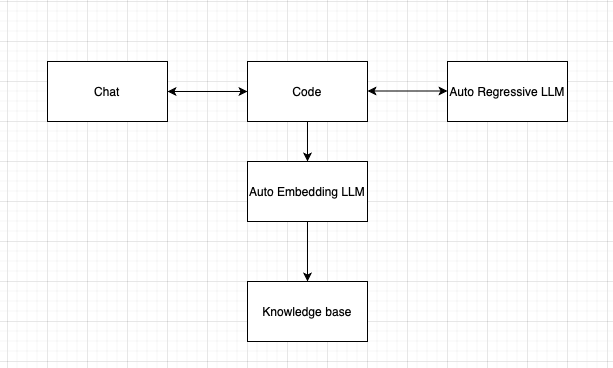

In [263]:
retriever = vectorstore.as_retriever()

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0
)


In [268]:
query = "what should be the maintenance strategy"

docs = retriever.invoke(query)
print("Number of chuncks fetched :", len(docs))

print(docs[3])

Number of chuncks fetched : 4
page_content='performance of the compressed air installation.
Maintenance makes up the smallest part of the 
installation’s total cost of ownership. It depends on 
how the installation has been planned in general 
and the particular choice of compressor and aux-
iliary equipment.
Costs can be reduced by combining condition mon-
itoring with other functions when using equipment 
for fully automatic operations, and monitoring of 
the compressor central plant. The total budget for 
maintenance is affected by:
- Type of compressors
- Auxiliary equipment
 
(dryers, fi
 lters, control and regulation 
 
equipment)
- Operating cycle load/unload
- Installation conditions
- Media quality
- Maintenance planning
- Choice of safety level
- Energy recovery/cooling system
- Degree of utilization
The annual maintenance cost is usually between 
5–10% of the machine’s investment value.
4.2.7.1 Maintenance planning
Well-planned compressor maintenance allows 
costs to be anti

In [230]:
def retrieve(question):
    docs = retriever.invoke(question)
    print(f"Length of docs is {len(docs)}" )
    return docs

In [269]:
system_message = """
You are a helpful assistant for a manufacturing plant.
Give short, courteous answers.
Always be accurate. If you don't know the answer, say so.
"""

def answer_question(question: str, history):
    docs = retrieve(question)
    print("Docs:", docs)
    print("Type:", type(docs))
    context = "\n\n".join(doc.page_content for doc in docs)
    system_prompt = system_message.format(context=context)
    response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=question)])
    return response.content



In [270]:
gr.ChatInterface(answer_question).launch()

/Users/I072374/Sharath/Projects/AILearning/AILearning/LLM/.venv/lib/python3.12/site-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7889
* To create a public link, set `share=True` in `launch()`.


Length of docs is 4
Docs: [Document(id='41572960-fe81-425f-b32d-283ea7447074', metadata={'page': 36, 'source': 'knowledge/heat_pump.pdf'}, page_content='3.3\t Factory-Supplied Accessories.................................................................................................................7\n3.4\t Necessary Tools and Instrument List for Installation...............................................................................7\n4.\t Installation Location.........................................................................................................................................8\n5.\t Installation Work..............................................................................................................................................8\n5.1\t Suspension Bolts.\n....................................................................................................................................8\n5.2\t Marking Positions for Suspension Bolts and Piping Connecti